# Degree Distribution: Real vs. Null Models

### Tools:
Claude was used for error correction and code restructuring.

### Required Files:
`Edges.csv`

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Palette 
C_DATA = '#27AE60'   
C_ER   = '#2980B9'   
C_DP   = '#E74C3C'   
BG     = "#FFFFFF"   

plt.rcParams.update({
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 130,
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
})

In [6]:
# Load the edges file and build the full graph
edges = pd.read_csv("Edges.csv")
# nx.from_pandas_edgelist: https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html
G = nx.from_pandas_edgelist(edges, source='Source', target='Target', edge_attr='Weight')

# Extract the Largest Connected Component
# nx.connected_components: https://networkx.org/documentation/stable/reference/algorithms/component.html
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# Extract properties needed to build the null models
n          = LCC.number_of_nodes()
p          = nx.density(LCC)
degree_seq = [d for _, d in LCC.degree()]

# number of null model networks to generate
N_ENSEMBLE = 1000  

# Build a single ER null model
# Generate ensemble of 1000 ER networks and pool all degree sequences
# nx.erdos_renyi_graph: https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.erdos_renyi_graph.html
print(f"Generating {N_ENSEMBLE} ER networks")
er_all_degs = []
for i in range(N_ENSEMBLE):
    er_g = nx.erdos_renyi_graph(n, p, seed=i)
    er_all_degs.extend([d for _, d in er_g.degree()])

# Generate ensemble of 1000 configuration model networks and pool all degree sequences
# nx.configuration_model: https://networkx.org/documentation/stable/reference/generated/networkx.generators.degree_seq.configuration_model.html
print(f"Generating {N_ENSEMBLE} Configuration Model networks")
dp_all_degs = []
for i in range(N_ENSEMBLE):
    cm = nx.configuration_model(degree_seq, seed=i)
    # convert to simple graph
    cm = nx.Graph(cm)  
    # remove self-loops
    cm.remove_edges_from(nx.selfloop_edges(cm))    
    dp_all_degs.extend([d for _, d in cm.degree()])

# Extract and sort degree sequences for plotting
real_deg = sorted([d for _, d in LCC.degree()])
er_deg   = sorted(er_all_degs)
dp_deg   = sorted(dp_all_degs)

print(f"Real  mean={np.mean(real_deg):.2f}  max={max(real_deg)}")
print(f"ER    mean={np.mean(er_deg):.2f}   max={max(er_deg)}")
print(f"DP    mean={np.mean(dp_deg):.2f}  max={max(dp_deg)}")

Generating 1000 ER networks
Generating 1000 Configuration Model networks
Real  mean=13.30  max=62
ER    mean=13.29   max=32
DP    mean=12.72  max=61


## Graph 1 Degree Distribution: Real vs. ER vs. Config Model

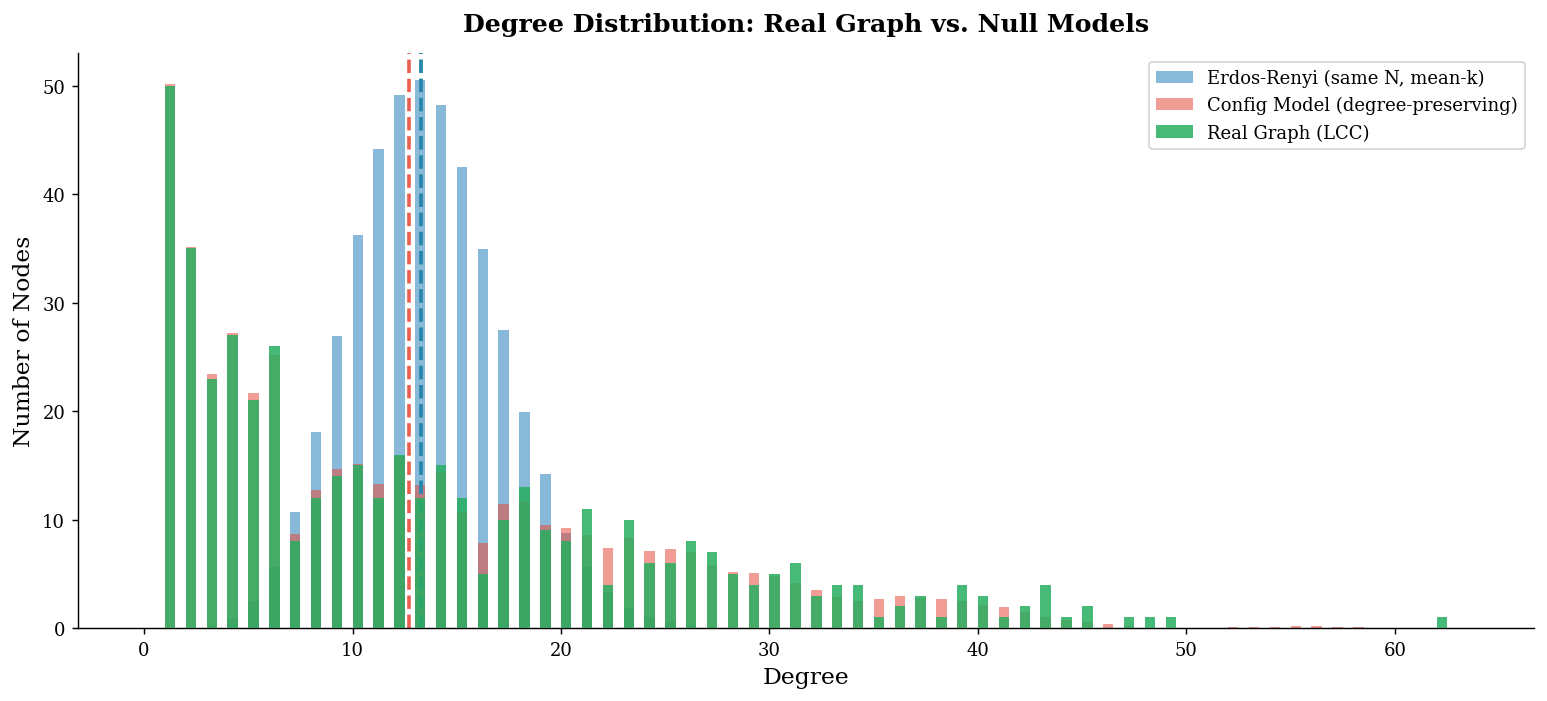

Saved -> degree_dist_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Set bin width to 0.5 so each integer degree gets its own bar
max_deg = max(real_deg + er_deg + dp_deg)
bins    = np.arange(0, max_deg + 2, 0.5)

# Normalize counts by dividing by ensemble size so y-axis shows average node count per network
# This makes the null model distributions directly comparable to the real graph
weights_er   = np.ones(len(er_deg))   / N_ENSEMBLE
weights_dp   = np.ones(len(dp_deg))   / N_ENSEMBLE
weights_real = np.ones(len(real_deg))

# Plot null models first so the real graph sits on top
ax.hist(er_deg,   bins=bins, alpha=0.55, color=C_ER,   weights=weights_er,
        label='Erdos-Renyi (same N, mean-k)',     zorder=1)
ax.hist(dp_deg,   bins=bins, alpha=0.55, color=C_DP,   weights=weights_dp,
        label='Config Model (degree-preserving)', zorder=2)
ax.hist(real_deg, bins=bins, alpha=0.85, color=C_DATA, weights=weights_real,
        label='Real Graph (LCC)',                 zorder=3)

# Dashed mean lines per model
ax.axvline(np.mean(real_deg), color=C_DATA, linestyle='--', linewidth=2.0, alpha=0.9)
ax.axvline(np.mean(er_deg),   color=C_ER,   linestyle='--', linewidth=2.0, alpha=0.9)
ax.axvline(np.mean(dp_deg),   color=C_DP,   linestyle='--', linewidth=2.0, alpha=0.9)

ax.set_xlabel('Degree', fontsize=13)
ax.set_ylabel('Number of Nodes', fontsize=13)
ax.set_title('Degree Distribution: Real Graph vs. Null Models',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Graph 2 Degree Distribution: Real Graph Only (standalone slide)

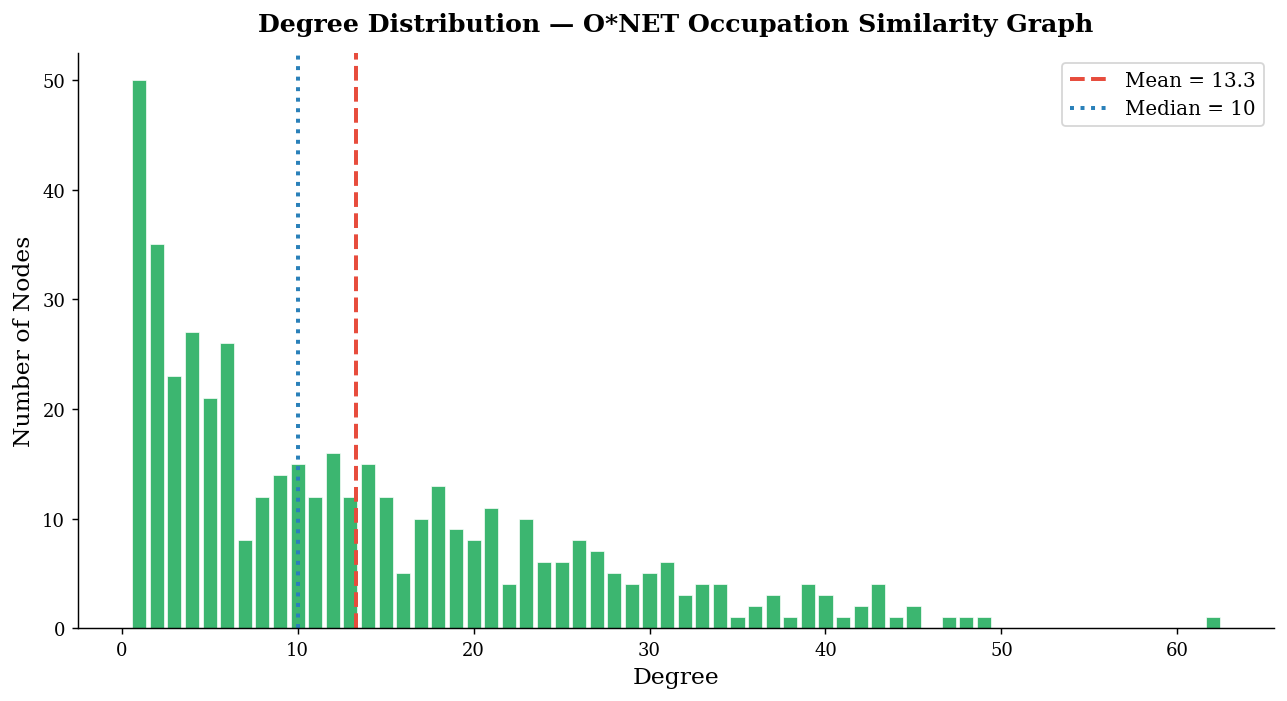

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Count how many nodes have each degree value and sort by degree
deg_counts = pd.Series(real_deg).value_counts().sort_index()

# Plot the degree distribution as a bar chart
ax.bar(deg_counts.index, deg_counts.values,
       color=C_DATA, edgecolor='white', linewidth=0.4, alpha=0.9)

# Compute mean and median to show on the plot
mean_deg   = np.mean(real_deg)
median_deg = np.median(real_deg)

ax.axvline(mean_deg,   color=C_DP, linestyle='--', linewidth=2.2,
           label=f'Mean = {mean_deg:.1f}')
ax.axvline(median_deg, color=C_ER, linestyle=':',  linewidth=2.2,
           label=f'Median = {median_deg:.0f}')

# Add vertical reference lines for mean and median
ax.set_xlabel('Degree', fontsize=13)
ax.set_ylabel('Number of Nodes', fontsize=13)
ax.set_title('Degree Distribution — O*NET Occupation Similarity Graph',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, frameon=True)

plt.tight_layout()
plt.show()